# AutoAce Pipeline Experiments

Scratch space for iterating on the voice-tone / background-noise pipeline
outside of the FastAPI service — tune acoustic thresholds, inspect
transcripts, compare the LLM classifier against a lightweight
features-only classifier, and eyeball predictions vs. ground truth.

This notebook runs against **synthetic audio by default** so it works with
no setup. Point `LABELED_CALLS_DIR` at the real three labeled calls (same
shape as the batch-upload format: audio files + a `labels.csv` with
`name`/`result_json` columns) once you have them, and rerun from the top.

Run with: `uv run --group notebook jupyter lab` (or open directly in an
IDE's notebook UI pointed at the `backend/.venv` interpreter).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # make `app` importable from backend/notebooks/

import os
from dotenv import load_dotenv

load_dotenv(Path.cwd().parent / ".env")  # must run before any `app.*` import -- see note below

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from app.pipeline.acoustic_features import analyze
from app.pipeline.audio_io import load_mono_16k, TARGET_SR
from app.pipeline.transcribe import transcribe
from app.pipeline.pipeline import run_pipeline
from app.utils.csv_manifest import parse_and_validate

pd.set_option("display.max_colwidth", 60)

/Users/pranavchourasiya/pranav/ProsodyAi/backend/.venv/lib/python3.12/site-packages/webrtcvad.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/Users/pranavchourasiya/pranav/ProsodyAi/backend/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

Set this to the real labeled-calls directory when you have it. If it
doesn't exist, the next cell generates synthetic stand-ins so the rest of
the notebook still runs.

In [2]:
LABELED_CALLS_DIR = Path("../labeled_calls")  # <- point this at the real 3 labeled calls
USE_SYNTHETIC = not LABELED_CALLS_DIR.exists()
print(f"Using {'synthetic placeholder' if USE_SYNTHETIC else 'real labeled'} audio: {LABELED_CALLS_DIR}")

Using synthetic placeholder audio: ../labeled_calls


## Synthetic placeholder data

Three quick synthetic clips standing in for the real labeled calls, so the
pipeline can be exercised end-to-end (minus meaningful transcripts/tone,
obviously) before the real data arrives:

- `synth_clean.wav` — clear speech-like tone, no noise, no silence gaps
- `synth_noisy.wav` — same tone with broadband noise mixed in at low SNR
- `synth_silence.wav` — mostly silence with one short burst, clipped peak

These are NOT meant to validate accuracy — only to sanity-check that the
pipeline runs and to give the plotting/threshold cells something to show.

In [3]:
import soundfile as sf

SYNTH_DIR = Path("./_synthetic_calls")
SYNTH_DIR.mkdir(exist_ok=True)

def make_tone(duration_s, freq=180, sr=TARGET_SR, amp=0.3):
    t = np.linspace(0, duration_s, int(sr * duration_s), endpoint=False)
    # a few harmonics so it's less of a pure sine, closer to voiced speech energy
    return amp * (np.sin(2 * np.pi * freq * t) + 0.4 * np.sin(2 * np.pi * freq * 2 * t))

rng = np.random.default_rng(0)

if USE_SYNTHETIC:
    clean = make_tone(6.0)
    sf.write(SYNTH_DIR / "synth_clean.wav", clean, TARGET_SR)

    noisy = make_tone(6.0) + rng.normal(0, 0.12, int(TARGET_SR * 6.0))
    sf.write(SYNTH_DIR / "synth_noisy.wav", noisy, TARGET_SR)

    quiet_tail = make_tone(1.5)
    silence = np.zeros(int(TARGET_SR * 5.0))
    clipped_burst = np.clip(make_tone(1.0, amp=1.8), -1.0, 1.0)
    silence_clip = np.concatenate([quiet_tail, silence, clipped_burst])
    sf.write(SYNTH_DIR / "synth_silence.wav", silence_clip, TARGET_SR)

    labels_csv = SYNTH_DIR / "labels.csv"
    labels_csv.write_text(
        "name,result_json\n"
        'synth_clean.wav,"{}"\n'
        'synth_noisy.wav,"{}"\n'
        'synth_silence.wav,"{}"\n'
    )
    active_dir = SYNTH_DIR
else:
    active_dir = LABELED_CALLS_DIR

audio_files = sorted(p for p in active_dir.iterdir() if p.suffix.lower() in {".wav", ".mp3", ".m4a", ".ogg", ".flac"})
print(f"{len(audio_files)} audio file(s) in {active_dir}")
audio_files

3 audio file(s) in _synthetic_calls


[PosixPath('_synthetic_calls/synth_clean.wav'),
 PosixPath('_synthetic_calls/synth_noisy.wav'),
 PosixPath('_synthetic_calls/synth_silence.wav')]

## 1. Acoustic feature extraction

Runs the deterministic layer (`app/pipeline/acoustic_features.py`) on each
clip and lays the raw numeric features out in a table — this is the view
to use when tuning the SNR/clipping/silence thresholds.

In [4]:
feature_rows = []
loaded_audio = {}

for path in audio_files:
    audio, sr = load_mono_16k(str(path))
    loaded_audio[path.name] = (audio, sr)
    feat = analyze(audio, sr)
    row = {"file": path.name, **feat.raw}
    row["background_noise_present"] = feat.background_noise_present
    row["background_noise_severity"] = feat.background_noise_severity
    row["audio_quality"] = feat.audio_quality
    row["speaker_overlap_present"] = feat.speaker_overlap_present
    row["long_silence_present"] = feat.long_silence_present
    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows).set_index("file")
features_df

,speech_ratio,snr_db,clipping_fraction,mean_rms_dbfs,spectral_flatness,overlap_ratio,longest_silence_s,background_noise_present,background_noise_severity,audio_quality,speaker_overlap_present,long_silence_present
file,,,,,,,,,,,,
synth_clean.wav,0.015,0.032872,0.000,-12.823299,6.206480e-07,0.00,5.91,True,high,slightly_impaired,False,True
synth_noisy.wav,1.000,30.000000,0.000,-11.765032,1.266375e-01,0.15,0.00,False,none,clear,True,False
synth_silence.wav,0.160,60.000000,0.074,-10.053570,6.510723e-01,0.15,4.89,False,none,severely_impaired,True,True


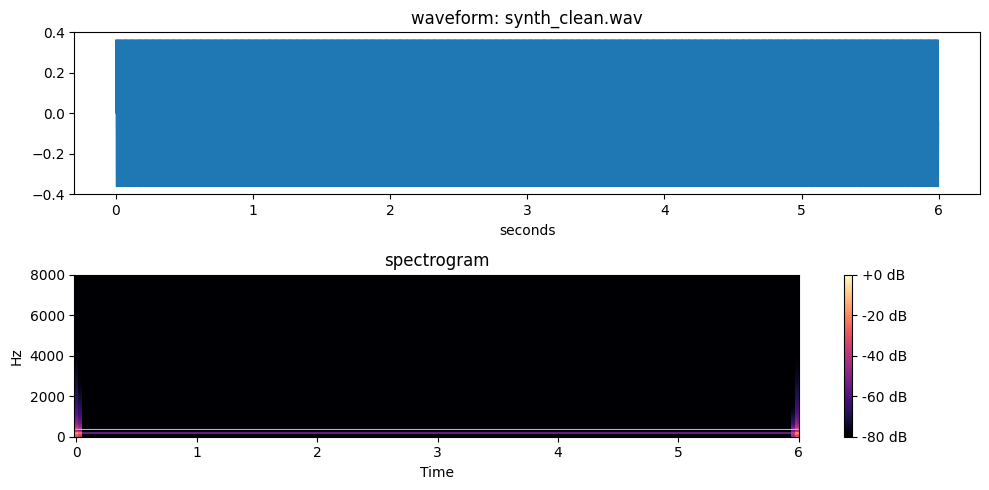

In [5]:
# Waveform + spectrogram for a quick visual sanity check. Change `pick` to inspect a different file.
import librosa.display

pick = audio_files[0].name
audio, sr = loaded_audio[pick]

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].plot(np.linspace(0, len(audio) / sr, len(audio)), audio, linewidth=0.5)
axes[0].set_title(f"waveform: {pick}")
axes[0].set_xlabel("seconds")

S = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
img = librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="hz", ax=axes[1])
axes[1].set_title("spectrogram")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
fig.tight_layout()

## 2. Threshold tuning playground

The production thresholds live in `app/pipeline/acoustic_features.py`
(`analyze()`). This cell re-derives `background_noise_severity` and
`audio_quality` from the already-computed raw features using adjustable
cutoffs, so you can see how a threshold change would shift predictions
across the whole set before editing the actual pipeline file.

In [6]:
def classify_noise(snr_db, low=22, med=15, high=8):
    if snr_db >= low:
        return False, "none"
    if snr_db >= med:
        return True, "low"
    if snr_db >= high:
        return True, "medium"
    return True, "high"

def classify_quality(clipping_fraction, mean_rms_dbfs, snr_db,
                      clip_severe=0.001, quiet_severe=-40, quiet_impaired=-30, snr_impaired=10):
    if clipping_fraction > clip_severe or mean_rms_dbfs < quiet_severe:
        return "severely_impaired"
    if clipping_fraction > 0 or mean_rms_dbfs < quiet_impaired or snr_db < snr_impaired:
        return "slightly_impaired"
    return "clear"

# Example: try a stricter noise-floor cutoff and see what changes
trial = features_df.copy()
trial[["noise_present_trial", "noise_severity_trial"]] = trial["snr_db"].apply(
    lambda snr: pd.Series(classify_noise(snr, low=25))  # <- tweak thresholds here
)
trial[["background_noise_severity", "noise_severity_trial", "snr_db"]]

,background_noise_severity,noise_severity_trial,snr_db
file,,,
synth_clean.wav,high,high,0.032872
synth_noisy.wav,none,none,30.000000
synth_silence.wav,none,none,60.000000


## 3. Transcription

Runs `faster-whisper` on each clip. On the synthetic tones this will
mostly come back empty/garbage (there's no actual speech) — that's
expected and is itself a useful check that the pipeline handles
empty-transcript clips gracefully. On real calls, read these to sanity
check tone/intensity judgments in the next section.

In [7]:
transcripts = {}
for path in audio_files:
    audio, sr = loaded_audio[path.name]
    transcripts[path.name] = transcribe(audio, sr)

pd.DataFrame({"transcript": transcripts}).rename_axis("file")

,transcript
file,
synth_clean.wav,
synth_noisy.wav,
synth_silence.wav,


## 4. LLM classification

Requires `OPENAI_API_KEY` in the environment -- loaded from `backend/.env`
at the top of this notebook (must happen before any `app.*` import, since
`app/config.py` reads env vars into class attributes at import time, not
lazily). Skips gracefully if it isn't set, so the rest of the notebook
still runs without a key.

In [8]:
has_key = bool(os.getenv("OPENAI_API_KEY"))
print("OPENAI_API_KEY set:", has_key)

OPENAI_API_KEY set: True


In [9]:
from app.pipeline.classify import classify

llm_results = {}
if has_key:
    for path in audio_files:
        feat = analyze(*loaded_audio[path.name])
        llm_results[path.name] = classify(transcripts[path.name], feat)
    display(pd.DataFrame(llm_results).T)
else:
    print("Skipping — set OPENAI_API_KEY to run this cell.")

,emotional_tone,emotional_intensity,background_noise_type,confidence
synth_clean.wav,neutral,low,,0.9
synth_noisy.wav,neutral,low,,0.9
synth_silence.wav,neutral,low,,0.9


## 5. Full pipeline vs. ground truth

Runs the complete `run_pipeline()` (acoustic + transcription + LLM) on
every file and compares against `result_json` in the manifest, when
present. This mirrors `scripts/evaluate.py` but interactively, for poking
at individual mismatches.

In [10]:
manifest_path = active_dir / "labels.csv"
audio_names = {p.name for p in audio_files}
validation = parse_and_validate(manifest_path.read_bytes(), audio_names) if manifest_path.exists() else None

pipeline_rows = []
for path in audio_files:
    if not has_key:
        break
    outcome = run_pipeline(str(path))
    pred = outcome.prediction.model_dump()
    expected_raw = validation.matched.get(path.name) if validation else None
    expected = json.loads(expected_raw) if expected_raw else {}
    row = {"file": path.name, "duration_s": round(outcome.duration_s, 1), "processing_ms": outcome.processing_ms}
    for field, value in pred.items():
        row[f"pred_{field}"] = value
        if field in expected:
            row[f"true_{field}"] = expected[field]
            row[f"match_{field}"] = value == expected[field]
    pipeline_rows.append(row)

pipeline_df = pd.DataFrame(pipeline_rows).set_index("file") if pipeline_rows else pd.DataFrame()
pipeline_df

,duration_s,processing_ms,pred_emotional_tone,pred_emotional_intensity,pred_background_noise_present,pred_background_noise_type,pred_background_noise_severity,pred_audio_quality,pred_speaker_overlap_present,pred_long_silence_present,pred_confidence
file,,,,,,,,,,,
synth_clean.wav,6.0,4108,EmotionalTone.neutral,EmotionalIntensity.low,True,,NoiseSeverity.high,AudioQuality.slightly_impaired,False,True,0.9
synth_noisy.wav,6.0,1244,EmotionalTone.neutral,EmotionalIntensity.low,False,,NoiseSeverity.none,AudioQuality.clear,True,False,0.9
synth_silence.wav,7.5,3885,EmotionalTone.neutral,EmotionalIntensity.low,False,,NoiseSeverity.none,AudioQuality.severely_impaired,True,True,0.9


## 6. Alternative approach: acoustic-features-only classifier

The brief asks for at least two materially different approaches to be
compared (see MEMO.md). The production pipeline already splits noise/
quality/overlap/silence (acoustic) from tone/intensity (LLM) — this
section sketches the *other* comparison point: predicting `emotional_tone`
from acoustic features alone (no transcript, no LLM), as a cheaper/faster
fallback.

With only three labeled calls this can't be meaningfully trained or
validated — the code below is structural scaffolding for when more labeled
data exists, not a working classifier yet. Don't trust its output on three
rows.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

FEATURE_COLS = ["speech_ratio", "snr_db", "clipping_fraction", "mean_rms_dbfs", "spectral_flatness", "overlap_ratio"]

def build_training_frame(active_dir, validation):
    if validation is None:
        return None
    rows = []
    for name, expected_raw in validation.matched.items():
        if not expected_raw:
            continue
        expected = json.loads(expected_raw)
        if "emotional_tone" not in expected:
            continue
        audio, sr = load_mono_16k(str(active_dir / name))
        feat = analyze(audio, sr)
        rows.append({**{c: feat.raw[c] for c in FEATURE_COLS}, "emotional_tone": expected["emotional_tone"]})
    return pd.DataFrame(rows)

training_df = build_training_frame(active_dir, validation)

if training_df is None or len(training_df) < 4 or training_df["emotional_tone"].nunique() < 2:
    print(
        f"Not enough labeled, class-diverse data to fit/validate a classifier yet "
        f"({0 if training_df is None else len(training_df)} usable rows). "
        "This is expected with only three labeled calls -- revisit once more data is available."
    )
else:
    X = training_df[FEATURE_COLS].values
    y = training_df["emotional_tone"].values
    preds = []
    for train_idx, test_idx in LeaveOneOut().split(X):
        clf = LogisticRegression(max_iter=1000).fit(X[train_idx], y[train_idx])
        preds.append(clf.predict(X[test_idx])[0])
    print(f"Leave-one-out accuracy: {accuracy_score(y, preds):.2f} (n={len(y)})")

Not enough labeled, class-diverse data to fit/validate a classifier yet (0 usable rows). This is expected with only three labeled calls -- revisit once more data is available.


## Notes / next steps

- Swap `LABELED_CALLS_DIR` to the real three calls and rerun from the top
  once they're available.
- Any threshold change validated in section 2 needs to be copied back into
  `app/pipeline/acoustic_features.py` — this notebook doesn't modify the
  production pipeline.
- Section 6 is a placeholder until there's enough labeled data to train and
  validate an acoustic-only classifier properly; see MEMO.md's "next steps"
  for the same point in the context of the full deliverable.